# Week 3 (Start) — Model Evaluation & Hyperparameter Tuning (Solutions)



## 0. Setup: Imports and dataset loading
In the code cell below we import the required libraries and load the Iris dataset into a DataFrame.

In [21]:
# Imports and load Iris dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, precision_recall_fscore_support
from scipy import stats

# Load iris dataset as DataFrame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
# Ensure we have a human-friendly class name column
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))
X = df[iris.feature_names]
y = df['target']

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  


## 1. Exploratory Data Analysis (EDA)
Compute descriptive statistics, check class balance, and print missing values.

In [22]:
# EDA
print("Descriptive statistics:")
print(df.describe().T)

print('Class distribution:')
print(y.value_counts())

print('Missing values per column:')
print(df.isnull().sum())

Descriptive statistics:
                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0
Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64
Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64


## 2. Data Visualization
Pairplot and correlation heatmap to inspect relationships between features.

<Figure size 800x600 with 0 Axes>

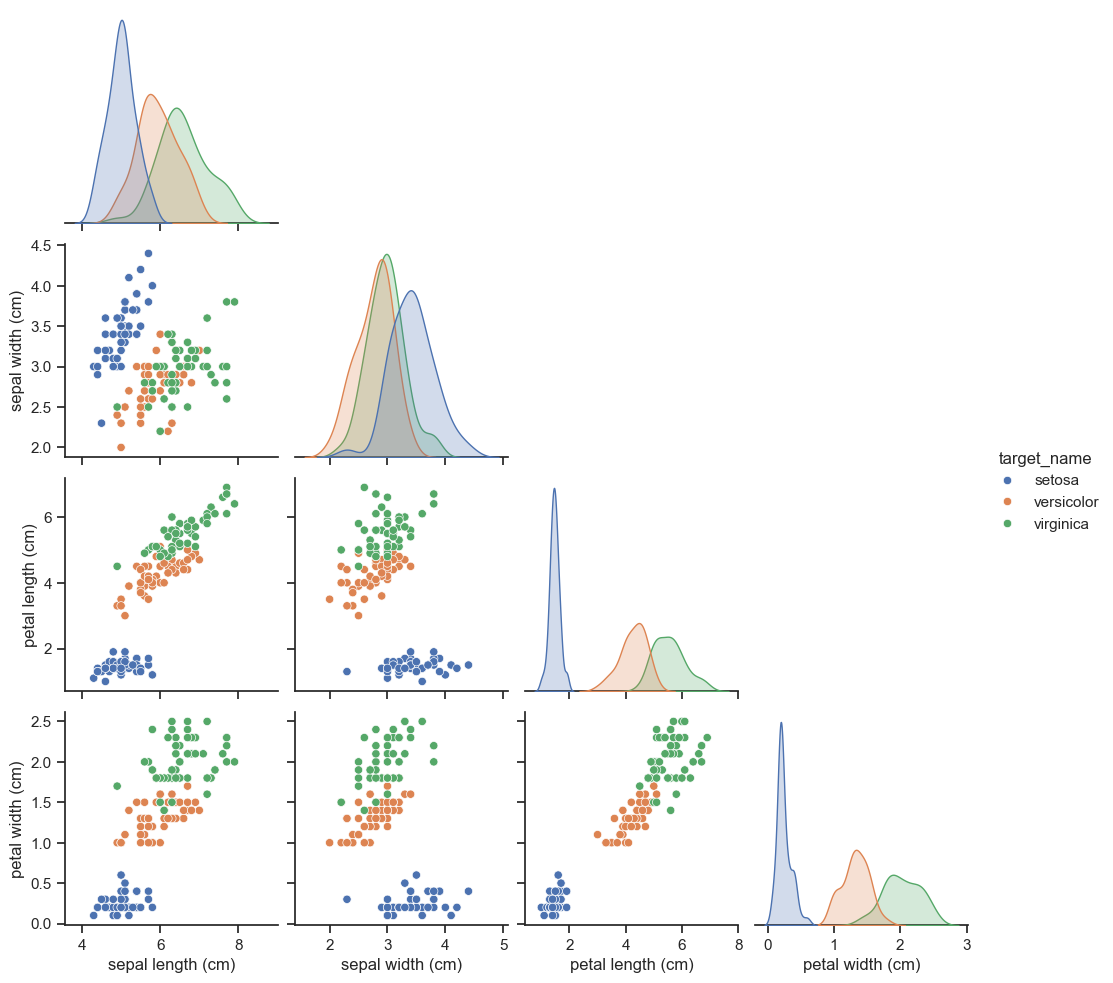

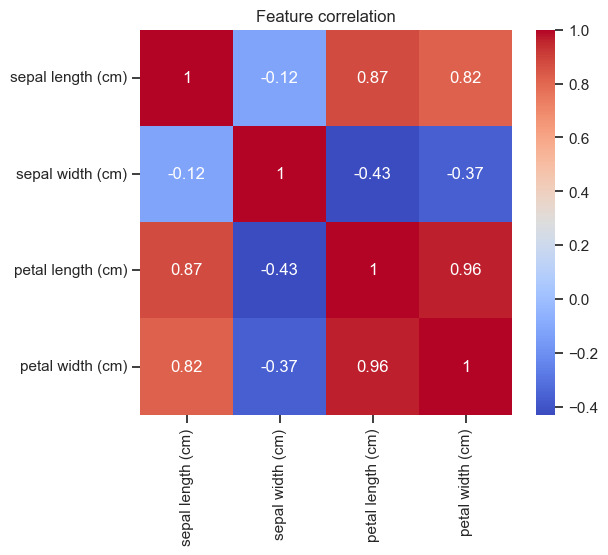

In [23]:
# Pairplot and correlation heatmap
sns.set(style='ticks')
plt.figure(figsize=(8,6))
sns.pairplot(df, vars=iris.feature_names, hue='target_name', corner=True)
plt.show()

# Correlation heatmap for numeric features
corr = X.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

## 3. Feature Engineering / PCA (optional)
Standardize features and run PCA (2 components). Visualize the 2D projection colored by class.

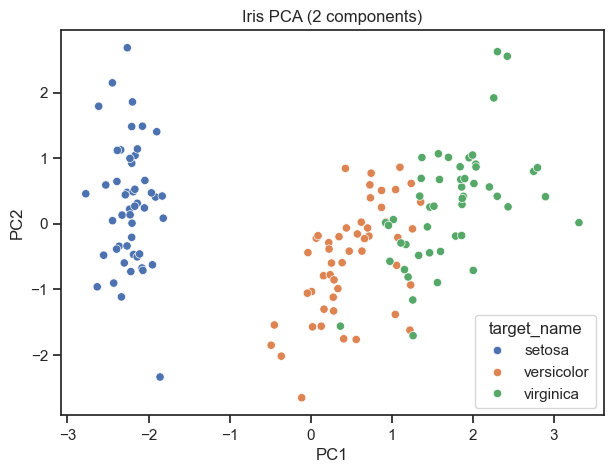

In [24]:
# Scale features and run PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA projection
pc_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pc_df['target'] = y.values
pc_df['target_name'] = pc_df['target'].map(dict(enumerate(iris.target_names)))
plt.figure(figsize=(7,5))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target_name', palette='deep')
plt.title('Iris PCA (2 components)')
plt.show()

## 4. Data Preparation (train/test split and scaling)
Split into train/test (stratified) and scale features.

In [25]:
# Train/test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


## 5. Baseline Models: Train & Evaluate
Train Logistic Regression and Random Forest; report classification metrics and confusion matrix.

Logistic Regression classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      0.60      0.71        10
           2       0.69      0.90      0.78        10

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.83        30
weighted avg       0.85      0.83      0.83        30



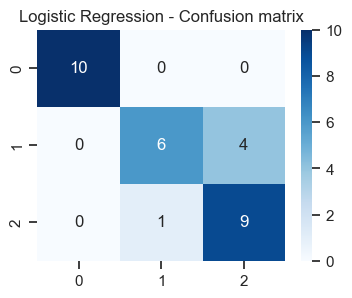

Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



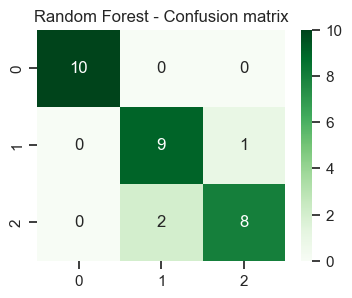

In [30]:
# Train baseline models and evaluate
log = LogisticRegression(solver='liblinear', random_state=42)
rf = RandomForestClassifier(random_state=42)

log.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# Evaluate Logistic Regression
print('Logistic Regression classification report:')
print(classification_report(y_test, yhat_log))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, yhat_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion matrix')
plt.show()

# Evaluate Random Forest
yhat_rf = rf.predict(X_test_scaled)
print('Random Forest classification report:')
print(classification_report(y_test, yhat_rf))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, yhat_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion matrix')
plt.show()

## 6. Cross-Validation Exercises
Run K-Fold, StratifiedKFold, and Leave-One-Out on Random Forest and report F1 scores.

In [ ]:
# Cross-validation experiments
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
loo = LeaveOneOut()

scores_kf = cross_val_score(rf, X, y, cv=kf, scoring='f1_macro')
scores_skf = cross_val_score(rf, X, y, cv=skf, scoring='f1_macro')
# LeaveOneOut is expensive; run only if the dataset is small (Iris has 150 samples)
scores_loo = cross_val_score(rf, X, y, cv=loo, scoring='f1_macro')

print('KFold F1 scores:', np.round(scores_kf, 3), 'mean=', np.round(scores_kf.mean(),3))
print('StratifiedKFold F1 scores:', np.round(scores_skf, 3), 'mean=', np.round(scores_skf.mean(),3))
print('LeaveOneOut F1 scores mean=', np.round(scores_loo.mean(),3))

KFold F1 scores: [1.    0.958 0.926 0.939 0.971] mean= 0.959
StratifiedKFold F1 scores: [0.967 0.967 0.933 0.967 0.9  ] mean= 0.946
LeaveOneOut F1 scores mean= 0.953


## 7. Hyperparameter Tuning (Guided) — Synthetic dataset
GridSearch on an imbalanced synthetic dataset for LogisticRegression. Compare metrics and ROC AUC before and after tuning.

In [ ]:
# Hyperparameter tuning (synthetic)
# 1) Create imbalanced synthetic dataset
X_syn, y_syn = make_classification(n_samples=2000, n_features=10, n_informative=3, n_redundant=1, n_clusters_per_class=1, weights=[0.9,0.1], flip_y=0.01, random_state=42)

# 2) Split and baseline LogisticRegression
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_syn, y_syn, test_size=0.2, stratify=y_syn, random_state=42)
scaler_syn = StandardScaler()
Xtr_s_scaled = scaler_syn.fit_transform(Xtr_s)
Xte_s_scaled = scaler_syn.transform(Xte_s)

log_base = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
log_base.fit(Xtr_s_scaled, ytr_s)
yhat_base = log_base.predict(Xte_s_scaled)
yprob_base = log_base.predict_proba(Xte_s_scaled)[:,1]
print('Baseline classification report:')
print(classification_report(yte_s, yhat_base))
print('Baseline ROC AUC:', np.round(roc_auc_score(yte_s, yprob_base),3))

# 3) GridSearchCV for LogisticRegression (tune C and penalty)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1','l2']}
grid = GridSearchCV(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(Xtr_s_scaled, ytr_s)
print('Best params:', grid.best_params_)

# 4) Refit and compare
best_log = grid.best_estimator_
yhat_best = best_log.predict(Xte_s_scaled)
yprob_best = best_log.predict_proba(Xte_s_scaled)[:,1]
print('Tuned classification report:')
print(classification_report(yte_s, yhat_best))
print('Tuned ROC AUC:', np.round(roc_auc_score(yte_s, yprob_best),3))

Baseline classification report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93       359
           1       0.48      0.98      0.65        41

    accuracy                           0.89       400
   macro avg       0.74      0.93      0.79       400
weighted avg       0.94      0.89      0.91       400

Baseline ROC AUC: 0.957
Best params: {'C': 10, 'penalty': 'l1'}
Tuned classification report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       359
           1       0.50      0.98      0.66        41

    accuracy                           0.90       400
   macro avg       0.75      0.93      0.80       400
weighted avg       0.95      0.90      0.91       400

Tuned ROC AUC: 0.957


## 7. Hyperparameter Tuning (Guided) — Breast Cancer
RandomizedSearchCV on the Breast Cancer dataset for RandomForest; compare baseline vs tuned.

In [ ]:
# Hyperparameter tuning (Breast Cancer)
bc = load_breast_cancer(as_frame=True)
df_bc = bc.frame.copy()
X_bc = df_bc[bc.feature_names]
y_bc = df_bc['target']
# train/test split and scaling
Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)
scaler_bc = StandardScaler()
Xbc_tr_s = scaler_bc.fit_transform(Xbc_tr)
Xbc_te_s = scaler_bc.transform(Xbc_te)

# Baseline RandomForest
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(Xbc_tr_s, ybc_tr)
yhat_base_bc = rf_base.predict(Xbc_te_s)
yprob_base_bc = rf_base.predict_proba(Xbc_te_s)[:,1]
print('Baseline Breast Cancer classification report:')
print(classification_report(ybc_te, yhat_base_bc))
print('Baseline ROC AUC:', np.round(roc_auc_score(ybc_te, yprob_base_bc),3))

# RandomizedSearchCV for RandomForest
param_dist = {
    'n_estimators': stats.randint(50, 150),
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': stats.randint(2, 11),
    'min_samples_leaf': stats.randint(1, 11),
    'max_features': ['sqrt', 'log2',None]
}

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
rs.fit(Xbc_tr_s, ybc_tr)
print('Best params (Randomized):', rs.best_params_)

# Evaluate tuned model
best_rf = rs.best_estimator_
yhat_best_bc = best_rf.predict(Xbc_te_s)
yprob_best_bc = best_rf.predict_proba(Xbc_te_s)[:, 1]
print('\nTuned Breast Cancer classification report:')
print(classification_report(ybc_te, yhat_best_bc))
print('Tuned ROC AUC:', np.round(roc_auc_score(ybc_te, yprob_best_bc), 3))

Baseline Breast Cancer classification report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Baseline ROC AUC: 0.994
Best params (Randomized): {'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 93}

Tuned Breast Cancer classification report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Tuned ROC AUC: 0.993


## 8. Overfitting vs Underfitting
Create underfit and overfit random forest models and compare training vs test accuracy. We'll use the Breast Cancer dataset prepared above.

In [ ]:
# Demonstrate overfitting vs underfitting (using breast cancer data)
rf_underfit = RandomForestClassifier(n_estimators=5, max_depth=2, random_state=42)
# use the tuned best_rf as a balanced model if available, otherwise use a medium complexity RF
rf_balanced = best_rf if 'best_rf' in globals() else RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_overfit = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)

models = {'underfit': rf_underfit, 'balanced': rf_balanced, 'overfit': rf_overfit}
for name, model in models.items():
    model.fit(Xbc_tr_s, ybc_tr)
    train_acc = model.score(Xbc_tr_s, ybc_tr)
    test_acc = model.score(Xbc_te_s, ybc_te)
    print(f'{name}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}')

underfit: train_acc=0.958, test_acc=0.956
balanced: train_acc=0.987, test_acc=0.956
overfit: train_acc=1.000, test_acc=0.956
